# 05 — Bike Sharing Explanatory Visualizations

## Objective

This notebook converts validated analytical findings into a focused set of presentation-ready visualizations.

The charts communicate:

- how demand changed between 2011 and 2012;
- how casual and registered users follow different temporal patterns;
- how calendar and weather conditions are associated with demand;
- what these patterns imply for operational planning.

This notebook does not repeat the full exploratory analysis. It presents only findings supported by the data audit, exploratory analysis, JMP analysis, and time-series regression.

In [1]:
from pathlib import Path
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## 1. Project paths and output folder

The clean daily and hourly datasets are loaded from the project structure.

Presentation-ready figures are saved separately from exploratory figures.

In [2]:
def find_project_root(start_path: Path) -> Path:
    """Find the nearest parent folder containing the project structure."""

    candidate_paths = [start_path, *start_path.parents]

    for path in candidate_paths:
        if (path / "01_data").exists() and (path / "02_python").exists():
            return path

    raise FileNotFoundError(
        "Project root was not found. "
        "Open the notebook from inside the bike-sharing project."
    )


project_root = find_project_root(Path.cwd().resolve())

day_data_path = (
    project_root
    / "01_data"
    / "clean"
    / "day_clean.csv"
)

hour_data_path = (
    project_root
    / "01_data"
    / "clean"
    / "hour_clean.csv"
)

presentation_figures_path = (
    project_root
    / "04_outputs"
    / "figures"
    / "presentation"
)

presentation_figures_path.mkdir(
    parents=True,
    exist_ok=True
)

print("project root:")
print(project_root)

print("\ndaily data exists:", day_data_path.exists())
print("hourly data exists:", hour_data_path.exists())

print("\npresentation figures folder:")
print(presentation_figures_path)

project root:
D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis

daily data exists: True
hourly data exists: True

presentation figures folder:
D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis\04_outputs\figures\presentation


## 2. Load the clean datasets

The daily dataset supports annual, monthly, calendar, and weather charts.

The hourly dataset supports intraday demand-profile analysis.

In [3]:
day = pd.read_csv(
    day_data_path,
    parse_dates=["dteday"]
)

hour = pd.read_csv(
    hour_data_path,
    parse_dates=["dteday", "datetime"]
)

day = (
    day
    .sort_values("dteday")
    .reset_index(drop=True)
)

hour = (
    hour
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("daily shape:", day.shape)
print("hourly shape:", hour.shape)

print(
    "daily date range:",
    day["dteday"].min(),
    "to",
    day["dteday"].max()
)

print(
    "hourly datetime range:",
    hour["datetime"].min(),
    "to",
    hour["datetime"].max()
)

daily shape: (731, 25)
hourly shape: (17379, 28)
daily date range: 2011-01-01 00:00:00 to 2012-12-31 00:00:00
hourly datetime range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00


## 3. Minimal visualization-data validation

Only the checks required for the final charts are repeated here.

The complete data-quality assessment was performed in the audit and cleaning
notebooks.

In [4]:
day_required_columns = [
    "dteday",
    "year",
    "yr",
    "mnth",
    "weekday",
    "season_label",
    "workingday",
    "weather_label",
    "temp_c",
    "humidity_pct",
    "casual",
    "registered",
    "cnt"
]

hour_required_columns = [
    "datetime",
    "dteday",
    "hr",
    "workingday",
    "casual",
    "registered",
    "cnt"
]

missing_day_columns = [
    column
    for column in day_required_columns
    if column not in day.columns
]

missing_hour_columns = [
    column
    for column in hour_required_columns
    if column not in hour.columns
]

assert not missing_day_columns, (
    f"Missing daily columns: {missing_day_columns}"
)

assert not missing_hour_columns, (
    f"Missing hourly columns: {missing_hour_columns}"
)

assert len(day) == 731
assert len(hour) == 17379

assert day["dteday"].is_monotonic_increasing
assert hour["datetime"].is_monotonic_increasing

assert (
    day["cnt"]
    == day["casual"] + day["registered"]
).all()

assert (
    hour["cnt"]
    == hour["casual"] + hour["registered"]
).all()

print("required columns are available.")
print("daily observations:", len(day))
print("hourly observations:", len(hour))
print("demand identities are valid.")

required columns are available.
daily observations: 731
hourly observations: 17379
demand identities are valid.


In [5]:
day["year"] = day["dteday"].dt.year
day["month_num"] = day["dteday"].dt.month
day["weekday_num"] = day["weekday"].astype(int)

hour["hour_num"] = hour["hr"].astype(int)

month_labels = {
    month_number: calendar.month_abbr[month_number]
    for month_number in range(1, 13)
}

weekday_labels = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

workingday_labels = {
    0: "Non-working day",
    1: "Working day"
}

weather_labels = {
    "clear_or_partly_cloudy": "Clear / partly cloudy",
    "mist_or_cloudy": "Mist / cloudy",
    "light_rain_or_snow": "Light rain / snow",
    "heavy_rain_snow_or_fog": "Heavy rain / snow / fog"
}

print("helper columns and labels are ready.")

helper columns and labels are ready.


## 4. Visualization principles

The final charts follow these principles:

- one clear message per figure;
- message-oriented titles;
- consistent use of color;
- direct labels where practical;
- minimal visual clutter;
- accurate and explicit units;
- zero baselines for bar charts;
- no three-dimensional charts;
- no dual axes;
- no causal claims from observational data.

In [6]:
casual_color = "#E69F00"
registered_color = "#0072B2"

total_color = "#4D4D4D"
neutral_color = "#B8B8B8"
light_neutral_color = "#D9D9D9"

highlight_color = "#D55E00"
mist_color = "#8A8A8A"

text_color = "#2F2F2F"
muted_text_color = "#6F6F6F"
grid_color = "#E6E6E6"

year_2011_color = "#A7A7A7"
year_2012_color = "#0072B2"

In [7]:
plt.rcParams.update({
    "figure.figsize": (10, 5.8),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": text_color,
    "axes.labelcolor": text_color,
    "axes.titlecolor": text_color,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.color": text_color,
    "ytick.color": text_color,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "font.family": "DejaVu Sans"
})

print("visualization settings are ready.")

visualization settings are ready.


In [8]:
def style_axis(ax, grid_axis="y"):
    """Apply a clean and consistent chart style."""

    ax.grid(
        axis=grid_axis,
        color=grid_color,
        linewidth=0.8
    )

    ax.set_axisbelow(True)

    ax.spines["left"].set_color(grid_color)
    ax.spines["bottom"].set_color(grid_color)


def add_subtitle(ax, subtitle):
    """Add a small explanatory subtitle below the main title."""

    ax.text(
        0,
        1.015,
        subtitle,
        transform=ax.transAxes,
        fontsize=9.5,
        color=muted_text_color,
        ha="left",
        va="bottom"
    )


def add_source_note(fig, note):
    """Add a short source or interpretation note."""

    fig.text(
        0.01,
        0.01,
        note,
        fontsize=8,
        color=muted_text_color,
        ha="left"
    )


def save_figure(fig, file_name):
    """Save a final figure in the presentation folder."""

    file_path = presentation_figures_path / file_name

    fig.savefig(
        file_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    print("figure saved:")
    print(file_path)

## 5. Annual growth and segment contribution

### Chart brief

- Audience: operational and business managers
- Decision supported: understand the scale and source of demand growth
- Main message: demand increased strongly in 2012, primarily through registered users
- Data level: daily
- Metric: average daily rentals
- Chart type: stacked bar chart
- Interpretation limitation: descriptive comparison, not a causal estimate

In [9]:
annual_daily = (
    day
    .groupby("year", as_index=False)[
        ["casual", "registered", "cnt"]
    ]
    .mean()
    .sort_values("year")
    .reset_index(drop=True)
)

assert annual_daily["year"].tolist() == [2011, 2012]

cnt_2011 = annual_daily.loc[
    annual_daily["year"].eq(2011),
    "cnt"
].iloc[0]

cnt_2012 = annual_daily.loc[
    annual_daily["year"].eq(2012),
    "cnt"
].iloc[0]

registered_2011 = annual_daily.loc[
    annual_daily["year"].eq(2011),
    "registered"
].iloc[0]

registered_2012 = annual_daily.loc[
    annual_daily["year"].eq(2012),
    "registered"
].iloc[0]

annual_growth_pct = (
    (cnt_2012 / cnt_2011) - 1
) * 100

total_increase = cnt_2012 - cnt_2011
registered_increase = registered_2012 - registered_2011

registered_contribution_pct = (
    registered_increase / total_increase
) * 100

print(annual_daily.round(2))

print(
    "\nannual growth:",
    round(annual_growth_pct, 2),
    "%"
)

print(
    "registered contribution to increase:",
    round(registered_contribution_pct, 2),
    "%"
)

   year   casual  registered      cnt
0  2011   677.40     2728.36  3405.76
1  2012  1018.48     4581.45  5599.93

annual growth: 64.43 %
registered contribution to increase: 84.46 %


figure saved:
D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis\04_outputs\figures\presentation\01_annual_growth_and_segment_contribution.png


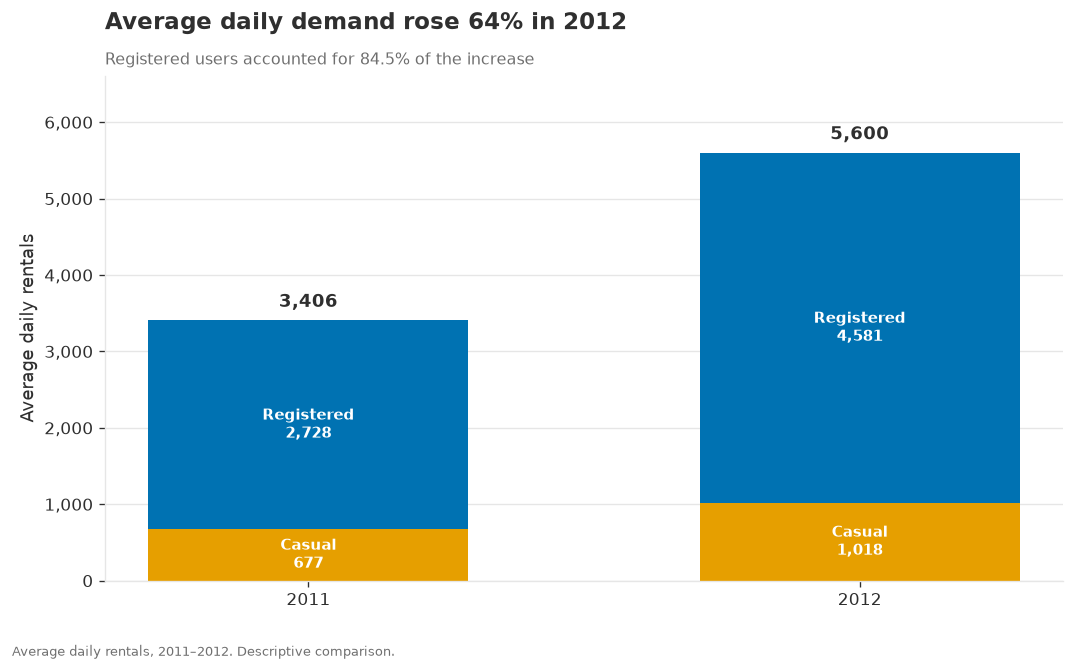

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

x_positions = np.arange(len(annual_daily))
bar_width = 0.58

casual_bars = ax.bar(
    x_positions,
    annual_daily["casual"],
    width=bar_width,
    color=casual_color
)

registered_bars = ax.bar(
    x_positions,
    annual_daily["registered"],
    width=bar_width,
    bottom=annual_daily["casual"],
    color=registered_color
)

for index, row in annual_daily.iterrows():
    casual_value = row["casual"]
    registered_value = row["registered"]
    total_value = row["cnt"]

    ax.text(
        index,
        casual_value / 2,
        f"Casual\n{casual_value:,.0f}",
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        index,
        casual_value + registered_value / 2,
        f"Registered\n{registered_value:,.0f}",
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        index,
        total_value + 120,
        f"{total_value:,.0f}",
        ha="center",
        va="bottom",
        color=text_color,
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    f"Average daily demand rose {annual_growth_pct:.0f}% in 2012",
    loc="left",
    pad=28
)

add_subtitle(
    ax,
    (
        f"Registered users accounted for "
        f"{registered_contribution_pct:.1f}% of the increase"
    )
)

ax.set_xticks(x_positions)
ax.set_xticklabels(
    annual_daily["year"].astype(str)
)

ax.set_ylabel("Average daily rentals")
ax.set_xlabel("")

ax.set_ylim(
    0,
    annual_daily["cnt"].max() * 1.18
)

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

style_axis(ax)

add_source_note(
    fig,
    "Average daily rentals, 2011–2012. Descriptive comparison."
)

fig.tight_layout(rect=[0, 0.05, 1, 0.93])

save_figure(
    fig,
    "01_annual_growth_and_segment_contribution.png"
)

plt.show()

## 6. Monthly demand trend

### Chart brief

- Audience: operations and capacity-planning managers
- Decision supported: identify seasonal demand build-up and peak periods
- Main message: 2012 demand remained above 2011 across the monthly cycle
- Data level: daily observations aggregated by month and year
- Metric: average daily rentals
- Chart type: line chart
- Interpretation limitation: monthly averages do not show within-month variation

In [11]:
monthly_demand = (
    day
    .groupby(
        ["year", "month_num"],
        as_index=False
    )["cnt"]
    .mean()
    .sort_values(
        ["year", "month_num"]
    )
)

monthly_demand["month_label"] = (
    monthly_demand["month_num"]
    .map(month_labels)
)

monthly_comparison = (
    monthly_demand
    .pivot(
        index="month_num",
        columns="year",
        values="cnt"
    )
)

months_2012_above_2011 = (
    monthly_comparison[2012]
    > monthly_comparison[2011]
).sum()

print(
    "months where 2012 exceeded 2011:",
    months_2012_above_2011,
    "of 12"
)

monthly_demand.head()

months where 2012 exceeded 2011: 12 of 12


,year,month_num,cnt,month_label
0,2011,1,1231.903226,Jan
1,2011,2,1721.964286,Feb
2,2011,3,2065.967742,Mar
3,2011,4,3162.333333,Apr
4,2011,5,4381.322581,May


figure saved:
D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis\04_outputs\figures\presentation\02_monthly_demand_trend.png


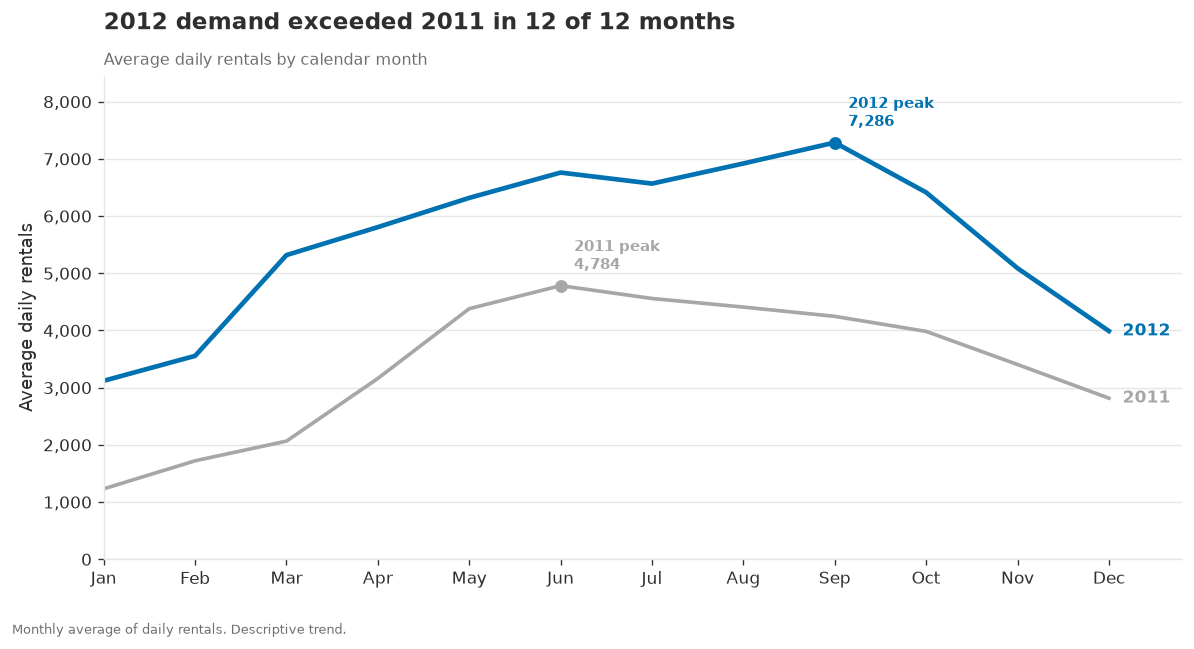

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.8))

year_styles = {
    2011: {
        "color": year_2011_color,
        "linewidth": 2.2
    },
    2012: {
        "color": year_2012_color,
        "linewidth": 2.8
    }
}

for year_value in [2011, 2012]:
    year_data = monthly_demand.loc[
        monthly_demand["year"].eq(year_value)
    ]

    ax.plot(
        year_data["month_num"],
        year_data["cnt"],
        color=year_styles[year_value]["color"],
        linewidth=year_styles[year_value]["linewidth"]
    )

    peak_row = year_data.loc[
        year_data["cnt"].idxmax()
    ]

    ax.scatter(
        peak_row["month_num"],
        peak_row["cnt"],
        color=year_styles[year_value]["color"],
        s=45,
        zorder=3
    )

    ax.annotate(
        (
            f"{year_value} peak\n"
            f"{peak_row['cnt']:,.0f}"
        ),
        xy=(
            peak_row["month_num"],
            peak_row["cnt"]
        ),
        xytext=(8, 10),
        textcoords="offset points",
        color=year_styles[year_value]["color"],
        fontsize=9,
        fontweight="bold"
    )

    final_row = year_data.iloc[-1]

    ax.text(
        12.15,
        final_row["cnt"],
        str(year_value),
        color=year_styles[year_value]["color"],
        fontsize=10,
        fontweight="bold",
        va="center"
    )

ax.set_title(
    (
        f"2012 demand exceeded 2011 in "
        f"{months_2012_above_2011} of 12 months"
    ),
    loc="left",
    pad=28
)

add_subtitle(
    ax,
    "Average daily rentals by calendar month"
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    [month_labels[month] for month in range(1, 13)]
)

ax.set_xlim(1, 12.8)
ax.set_ylim(
    0,
    monthly_demand["cnt"].max() * 1.16
)

ax.set_ylabel("Average daily rentals")
ax.set_xlabel("")

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

style_axis(ax)

add_source_note(
    fig,
    "Monthly average of daily rentals. Descriptive trend."
)

fig.tight_layout(rect=[0, 0.05, 1, 0.93])

save_figure(
    fig,
    "02_monthly_demand_trend.png"
)

plt.show()

## 7. Hourly user-segment profiles

### Chart brief

- Audience: fleet and rebalancing teams
- Decision supported: align hourly availability with different user behaviors
- Main message: casual and registered users peak at different times
- Data level: hourly
- Metric: each hour's share of the typical daily segment profile
- Chart type: line chart
- Interpretation limitation: the chart summarizes observed hourly patterns and is not a forecast

In [13]:
hourly_segment_mean = (
    hour
    .groupby("hour_num")[
        ["casual", "registered"]
    ]
    .mean()
    .reindex(range(24))
)

assert hourly_segment_mean.notna().all().all()

hourly_segment_share = (
    hourly_segment_mean
    .div(
        hourly_segment_mean.sum(axis=0),
        axis=1
    )
    * 100
)

casual_peak_hour = (
    hourly_segment_share["casual"]
    .idxmax()
)

registered_peak_hour = (
    hourly_segment_share["registered"]
    .idxmax()
)

print("casual peak hour:", casual_peak_hour)
print("registered peak hour:", registered_peak_hour)

casual peak hour: 14
registered peak hour: 17


figure saved:
D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis\04_outputs\figures\presentation\03_hourly_segment_profiles.png


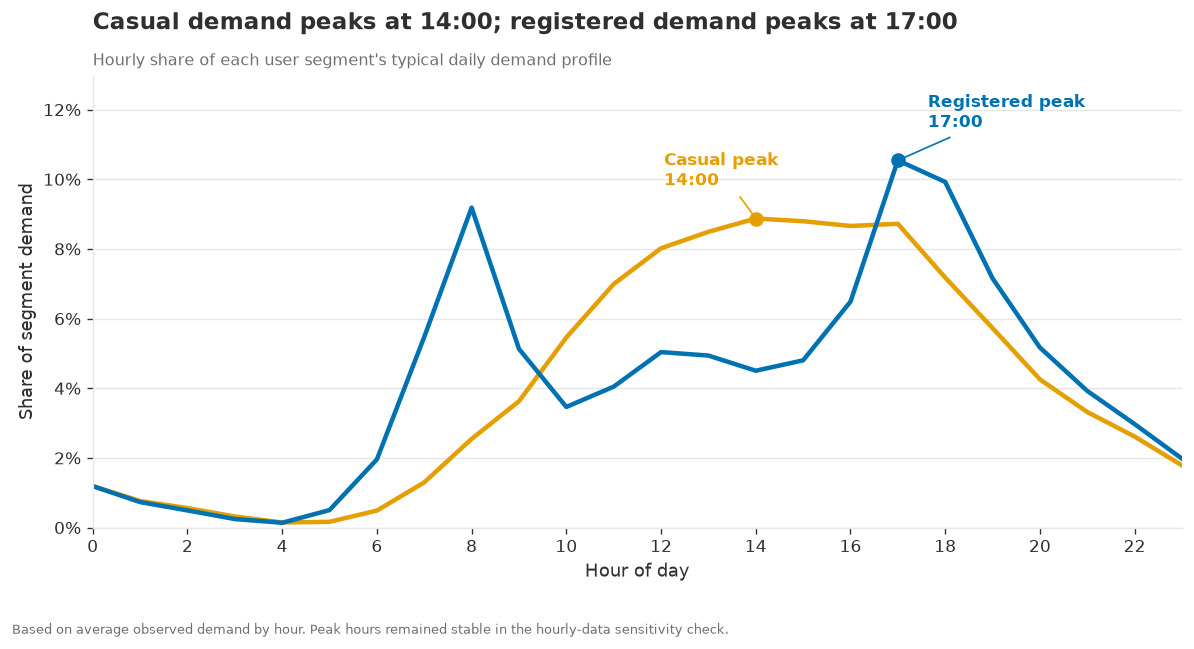

In [14]:
fig, ax = plt.subplots(figsize=(10, 5.8))

ax.plot(
    hourly_segment_share.index,
    hourly_segment_share["casual"],
    color=casual_color,
    linewidth=2.7
)

ax.plot(
    hourly_segment_share.index,
    hourly_segment_share["registered"],
    color=registered_color,
    linewidth=2.7
)

casual_peak_value = hourly_segment_share.loc[
    casual_peak_hour,
    "casual"
]

registered_peak_value = hourly_segment_share.loc[
    registered_peak_hour,
    "registered"
]

ax.scatter(
    casual_peak_hour,
    casual_peak_value,
    color=casual_color,
    s=60,
    zorder=3
)

ax.scatter(
    registered_peak_hour,
    registered_peak_value,
    color=registered_color,
    s=60,
    zorder=3
)

ax.annotate(
    f"Casual peak\n{casual_peak_hour}:00",
    xy=(casual_peak_hour, casual_peak_value),
    xytext=(-55, 20),
    textcoords="offset points",
    color=casual_color,
    fontsize=10,
    fontweight="bold",
    arrowprops={
        "arrowstyle": "-",
        "color": casual_color
    }
)

ax.annotate(
    f"Registered peak\n{registered_peak_hour}:00",
    xy=(registered_peak_hour, registered_peak_value),
    xytext=(18, 20),
    textcoords="offset points",
    color=registered_color,
    fontsize=10,
    fontweight="bold",
    arrowprops={
        "arrowstyle": "-",
        "color": registered_color
    }
)

ax.set_title(
    (
        f"Casual demand peaks at {casual_peak_hour}:00; "
        f"registered demand peaks at {registered_peak_hour}:00"
    ),
    loc="left",
    pad=28
)

add_subtitle(
    ax,
    "Hourly share of each user segment's typical daily demand profile"
)

ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 23)

ax.set_ylim(
    0,
    hourly_segment_share.max().max() * 1.23
)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Share of segment demand")

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(
        xmax=100,
        decimals=0
    )
)

style_axis(ax)

add_source_note(
    fig,
    (
        "Based on average observed demand by hour. "
        "Peak hours remained stable in the hourly-data sensitivity check."
    )
)

fig.tight_layout(rect=[0, 0.06, 1, 0.93])

save_figure(
    fig,
    "03_hourly_segment_profiles.png"
)

plt.show()

## 8. User mix by working-day status

### Chart brief

- Audience: fleet-allocation and operations managers
- Decision supported: allocate capacity according to user composition
- Main message: total demand changes modestly, but the user mix changes sharply
- Data level: daily
- Metric: average daily rentals
- Chart type: stacked bar chart


In [15]:
workingday_mix = (
    day
    .groupby("workingday", as_index=False)[
        ["casual", "registered", "cnt"]
    ]
    .mean()
    .sort_values("workingday")
    .reset_index(drop=True)
)

workingday_labels = {
    0: "Non-working day",
    1: "Working day"
}

workingday_mix["day_type"] = (
    workingday_mix["workingday"]
    .map(workingday_labels)
)

workingday_mix["casual_share_pct"] = (
    workingday_mix["casual"]
    / workingday_mix["cnt"]
    * 100
)

workingday_mix["registered_share_pct"] = (
    workingday_mix["registered"]
    / workingday_mix["cnt"]
    * 100
)

nonworking_total = workingday_mix.loc[
    workingday_mix["workingday"].eq(0),
    "cnt"
].iloc[0]

working_total = workingday_mix.loc[
    workingday_mix["workingday"].eq(1),
    "cnt"
].iloc[0]

workingday_total_change_pct = (
    (working_total / nonworking_total) - 1
) * 100

working_registered_share = workingday_mix.loc[
    workingday_mix["workingday"].eq(1),
    "registered_share_pct"
].iloc[0]

workingday_mix.round(2)

,workingday,casual,registered,cnt,day_type,casual_share_pct,registered_share_pct
0,0,1371.13,2959.03,4330.17,Non-working day,31.66,68.34
1,1,606.57,3978.25,4584.82,Working day,13.23,86.77


figure saved:
D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis\04_outputs\figures\presentation\04_user_mix_by_day_type.png


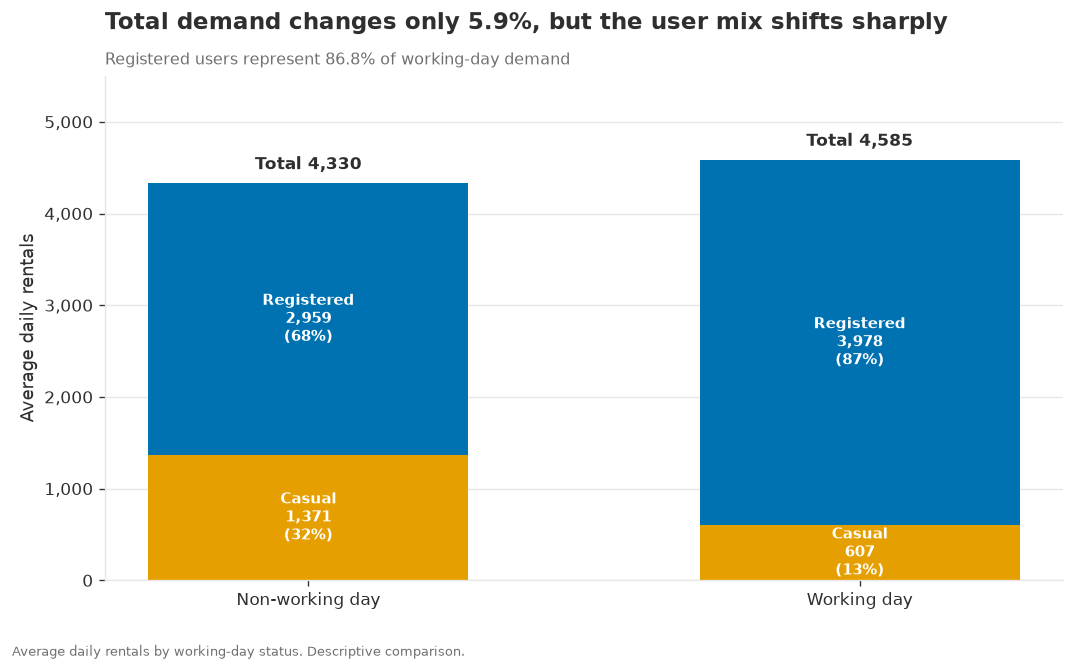

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

x_positions = np.arange(len(workingday_mix))
bar_width = 0.58

ax.bar(
    x_positions,
    workingday_mix["casual"],
    width=bar_width,
    color=casual_color
)

ax.bar(
    x_positions,
    workingday_mix["registered"],
    width=bar_width,
    bottom=workingday_mix["casual"],
    color=registered_color
)

for index, row in workingday_mix.iterrows():
    casual_value = row["casual"]
    registered_value = row["registered"]
    total_value = row["cnt"]

    ax.text(
        index,
        casual_value / 2,
        (
            f"Casual\n"
            f"{casual_value:,.0f}\n"
            f"({row['casual_share_pct']:.0f}%)"
        ),
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        index,
        casual_value + registered_value / 2,
        (
            f"Registered\n"
            f"{registered_value:,.0f}\n"
            f"({row['registered_share_pct']:.0f}%)"
        ),
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        index,
        total_value + 110,
        f"Total {total_value:,.0f}",
        ha="center",
        va="bottom",
        color=text_color,
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    (
        f"Total demand changes only {workingday_total_change_pct:.1f}%, "
        "but the user mix shifts sharply"
    ),
    loc="left",
    pad=28
)

add_subtitle(
    ax,
    (
        f"Registered users represent "
        f"{working_registered_share:.1f}% of working-day demand"
    )
)

ax.set_xticks(x_positions)
ax.set_xticklabels(
    workingday_mix["day_type"]
)

ax.set_ylabel("Average daily rentals")
ax.set_xlabel("")

ax.set_ylim(
    0,
    workingday_mix["cnt"].max() * 1.20
)

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

style_axis(ax)

add_source_note(
    fig,
    "Average daily rentals by working-day status. Descriptive comparison."
)

fig.tight_layout(rect=[0, 0.05, 1, 0.93])

save_figure(
    fig,
    "04_user_mix_by_day_type.png"
)

plt.show()

## 9. Casual demand by weekday

### Chart brief

- Audience: weekend operations and fleet-rebalancing teams
- Decision supported: prepare casual-user capacity by day of week
- Main message: casual demand is concentrated on weekends
- Data level: daily
- Metric: average daily casual rentals
- Chart type: bar chart
- Interpretation limitation: descriptive weekday pattern

In [17]:
weekday_order = list(range(7))

casual_weekday = (
    day
    .groupby("weekday_num", as_index=False)["casual"]
    .mean()
    .set_index("weekday_num")
    .reindex(weekday_order)
    .reset_index()
)

casual_weekday["weekday_label"] = (
    casual_weekday["weekday_num"]
    .map(weekday_labels)
)

weekend_mean = casual_weekday.loc[
    casual_weekday["weekday_num"].isin([0, 6]),
    "casual"
].mean()

weekday_mean = casual_weekday.loc[
    casual_weekday["weekday_num"].isin([1, 2, 3, 4, 5]),
    "casual"
].mean()

weekend_lift_pct = (
    (weekend_mean / weekday_mean) - 1
) * 100

print(casual_weekday.round(2))

print(
    "\nweekend lift versus weekdays:",
    round(weekend_lift_pct, 2),
    "%"
)

   weekday_num   casual weekday_label
0            0  1338.30        Sunday
1            1   674.13        Monday
2            2   556.18       Tuesday
3            3   551.14     Wednesday
4            4   590.96      Thursday
5            5   752.29        Friday
6            6  1465.26      Saturday

weekend lift versus weekdays: 124.3 %


figure saved:
D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis\04_outputs\figures\presentation\05_casual_demand_by_weekday.png


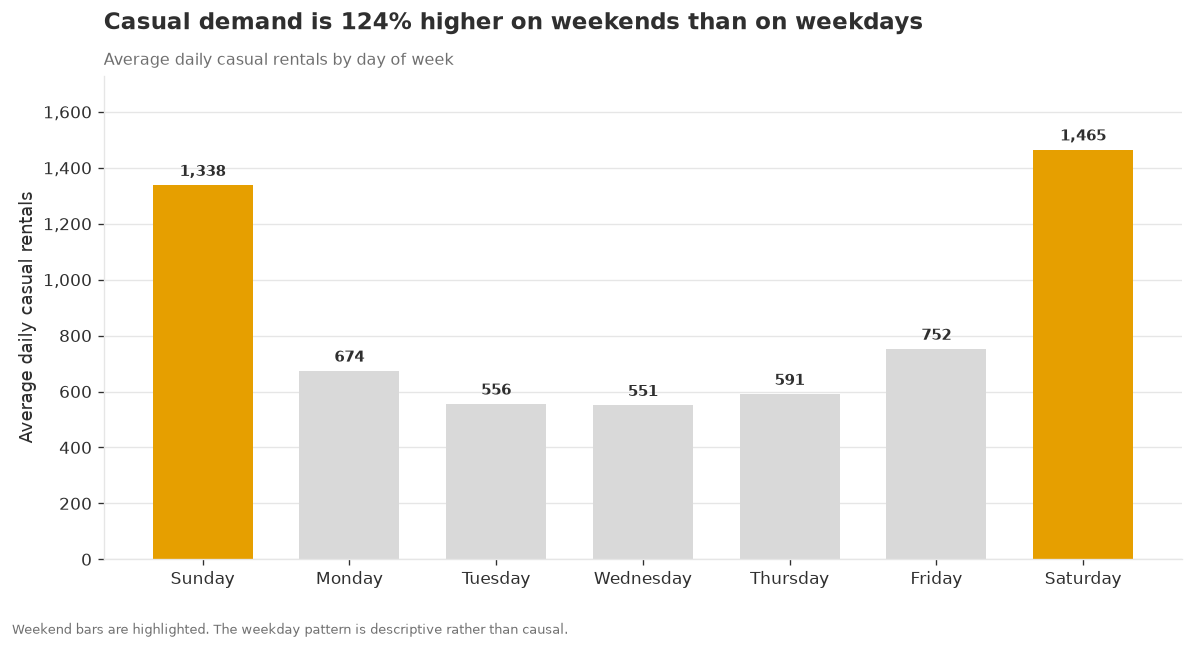

In [18]:
bar_colors = [
    casual_color
    if weekday_number in [0, 6]
    else light_neutral_color
    for weekday_number in casual_weekday["weekday_num"]
]

fig, ax = plt.subplots(figsize=(10, 5.8))

bars = ax.bar(
    casual_weekday["weekday_label"],
    casual_weekday["casual"],
    color=bar_colors,
    width=0.68
)

for bar, value in zip(
    bars,
    casual_weekday["casual"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 20,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=text_color,
        fontweight="bold"
    )

ax.set_title(
    (
        f"Casual demand is {weekend_lift_pct:.0f}% higher "
        "on weekends than on weekdays"
    ),
    loc="left",
    pad=28
)

add_subtitle(
    ax,
    "Average daily casual rentals by day of week"
)

ax.set_ylabel("Average daily casual rentals")
ax.set_xlabel("")

ax.set_ylim(
    0,
    casual_weekday["casual"].max() * 1.18
)

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

style_axis(ax)

add_source_note(
    fig,
    (
        "Weekend bars are highlighted. "
        "The weekday pattern is descriptive rather than causal."
    )
)

fig.tight_layout(rect=[0, 0.05, 1, 0.93])

save_figure(
    fig,
    "05_casual_demand_by_weekday.png"
)

plt.show()

## 10. Demand by weather condition

### Chart brief

- Audience: short-term operations and capacity-planning managers
- Decision supported: prepare capacity for favorable and adverse weather
- Main message: demand is highest under clear conditions and lower under light rain or snow
- Data level: daily
- Metric: average daily total rentals
- Chart type: ordered bar chart
- Interpretation limitation: descriptive association, not a causal effect

In [19]:
weather_order = [
    "clear_or_partly_cloudy",
    "mist_or_cloudy",
    "light_rain_or_snow",
    "heavy_rain_snow_or_fog"
]

weather_daily = (
    day
    .groupby("weather_label", as_index=False)
    .agg(
        average_daily_demand=("cnt", "mean"),
        observations=("cnt", "size")
    )
)

weather_daily = (
    weather_daily
    .set_index("weather_label")
    .reindex(weather_order)
    .dropna(
        subset=["average_daily_demand"]
    )
    .reset_index()
)

weather_daily["weather_display"] = (
    weather_daily["weather_label"]
    .map(weather_labels)
)

clear_demand = weather_daily.loc[
    weather_daily["weather_label"].eq(
        "clear_or_partly_cloudy"
    ),
    "average_daily_demand"
].iloc[0]

rain_demand = weather_daily.loc[
    weather_daily["weather_label"].eq(
        "light_rain_or_snow"
    ),
    "average_daily_demand"
].iloc[0]

weather_drop_pct = (
    1 - (rain_demand / clear_demand)
) * 100

heavy_weather_observed = (
    "heavy_rain_snow_or_fog"
    in set(day["weather_label"])
)

print(weather_daily.round(2))

print(
    "\nclear-to-rain demand drop:",
    round(weather_drop_pct, 2),
    "%"
)

print(
    "heavy weather observed:",
    heavy_weather_observed
)

            weather_label  average_daily_demand  observations  \
0  clear_or_partly_cloudy               4876.79         463.0   
1          mist_or_cloudy               4035.86         247.0   
2      light_rain_or_snow               1803.29          21.0   

         weather_display  
0  Clear / partly cloudy  
1          Mist / cloudy  
2      Light rain / snow  

clear-to-rain demand drop: 63.02 %
heavy weather observed: False


figure saved:
D:\کلاس دیتا\پاسخ تمارین\مصور سازی\fatemehkamrani_bike_sharing_demand_analysis\04_outputs\figures\presentation\06_demand_by_weather_condition.png


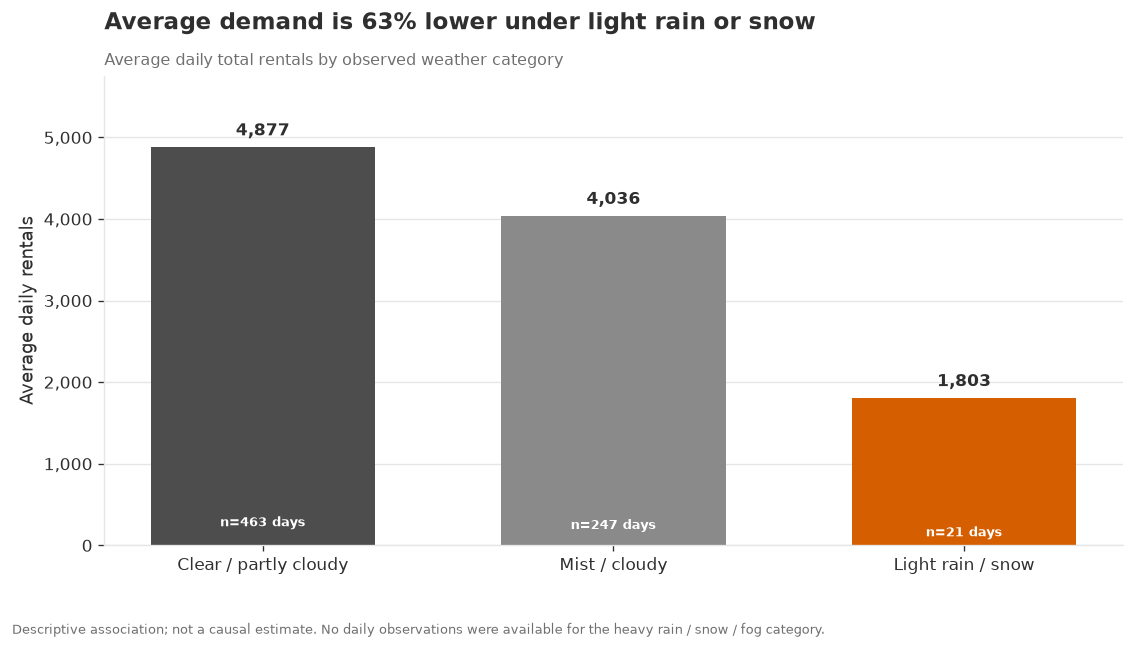

In [20]:
weather_color_map = {
    "clear_or_partly_cloudy": total_color,
    "mist_or_cloudy": mist_color,
    "light_rain_or_snow": highlight_color,
    "heavy_rain_snow_or_fog": highlight_color
}
weather_bar_colors = [
    weather_color_map[weather_value]
    for weather_value in weather_daily["weather_label"]
]

fig, ax = plt.subplots(figsize=(9.5, 5.8))

bars = ax.bar(
    weather_daily["weather_display"],
    weather_daily["average_daily_demand"],
    color=weather_bar_colors,
    width=0.64
)

for bar, demand_value, observation_count in zip(
    bars,
    weather_daily["average_daily_demand"],
    weather_daily["observations"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        demand_value + 100,
        f"{demand_value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color=text_color,
        fontweight="bold"
    )

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        demand_value * 0.04,
        f"n={int(observation_count)} days",
        ha="center",
        va="bottom",
        fontsize=8,
        color="white",
        fontweight="bold"
    )

ax.set_title(
    (
        f"Average demand is {weather_drop_pct:.0f}% lower "
        "under light rain or snow"
    ),
    loc="left",
    pad=28
)

add_subtitle(
    ax,
    "Average daily total rentals by observed weather category"
)

ax.set_ylabel("Average daily rentals")
ax.set_xlabel("")

ax.set_ylim(
    0,
    weather_daily[
        "average_daily_demand"
    ].max() * 1.18
)

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

style_axis(ax)

weather_note = (
    "Descriptive association; not a causal estimate."
)

if not heavy_weather_observed:
    weather_note += (
        " No daily observations were available for the "
        "heavy rain / snow / fog category."
    )

add_source_note(
    fig,
    weather_note
)

fig.tight_layout(rect=[0, 0.07, 1, 0.93])

save_figure(
    fig,
    "06_demand_by_weather_condition.png"
)

plt.show()

## 11. Final figure validation

The final check confirms that all required presentation figures were created
and saved in the dedicated presentation folder.

In [21]:
required_figure_files = [
    "01_annual_growth_and_segment_contribution.png",
    "02_monthly_demand_trend.png",
    "03_hourly_segment_profiles.png",
    "04_user_mix_by_day_type.png",
    "05_casual_demand_by_weekday.png",
    "06_demand_by_weather_condition.png"
]

figure_output_check = pd.DataFrame({
    "file_name": required_figure_files,
    "exists": [
        (
            presentation_figures_path
            / file_name
        ).exists()
        for file_name in required_figure_files
    ],
    "size_bytes": [
        (
            presentation_figures_path
            / file_name
        ).stat().st_size
        if (
            presentation_figures_path
            / file_name
        ).exists()
        else np.nan
        for file_name in required_figure_files
    ]
})

figure_output_check

,file_name,exists,size_bytes
0,01_annual_growth_and_segment_contribution.png,True,123764
1,02_monthly_demand_trend.png,True,188119
2,03_hourly_segment_profiles.png,True,245573
3,04_user_mix_by_day_type.png,True,154181
4,05_casual_demand_by_weekday.png,True,141481
5,06_demand_by_weather_condition.png,True,127729


In [22]:
assert figure_output_check["exists"].all(), (
    "At least one required figure is missing."
)

assert (
    figure_output_check["size_bytes"] > 0
).all(), (
    "At least one figure file is empty."
)

print("all six presentation figures are available.")
print("all figure files contain data.")
print("the explanatory-visualization notebook is complete.")

all six presentation figures are available.
all figure files contain data.
the explanatory-visualization notebook is complete.


## 12. Communication conclusions

The explanatory figures support five main operational conclusions:

1. Average daily demand increased substantially in 2012, and most of the
   increase was observed among registered users.

2. Casual and registered users follow different intraday patterns. Casual
   demand peaks in the afternoon, while registered demand peaks later in the
   day.

3. Total daily demand changes only modestly between working and non-working
   days, but the composition of users changes sharply.

4. Casual demand is concentrated on weekends, indicating a stronger leisure
   and discretionary-use pattern.

5. Demand is highest under clear conditions and lower under adverse weather.
   These relationships are descriptive and should not be interpreted as causal.

Operational planning should therefore combine:

- reliable working-day availability for registered users;
- stronger weekend preparation for casual users;
- intraday rebalancing based on segment-specific peak hours;
- weather-sensitive short-term capacity adjustments.